In [1]:
import pandas as pd
import numpy as np
import re
import gc #for my 8GB of RAM
import matplotlib.pyplot as plt
import seaborn as sns

# Visualises all columns
pd.set_option('display.max_colwidth', None)

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scarichiamo i pacchetti necessari (solo la prima volta)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /home/giuly/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/giuly/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/giuly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/giuly/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/giuly/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
df = pd.read_csv('../data/processed/greenwashing_dataset_filtered.csv', parse_dates=['Timestamp'])

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nContent types:\n{df['content_type'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTimestamp range: {df['Timestamp'].min()} → {df['Timestamp'].max()}")
df.sample(5)

In [5]:
def preprocess_text(text):
    if pd.isna(text):
        return ''
    # 1. lowercase
    text = text.lower()
    # 2. remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. tokenize
    tokens = word_tokenize(text)
    # 4. remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # 5. lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [6]:
print("Preprocessing...")
df['text_clean'] = df['Text'].apply(preprocess_text)

# quick sanity check
print(f"Done. Empty texts after preprocessing: {(df['text_clean'] == '').sum()}")
df[['Text', 'text_clean']].sample(3)

Preprocessing...
Done. Empty texts after preprocessing: 2


,Text,text_clean
11837,"Honestly, I don't think that apps and extensions and things like that are the solution. Apps that suggest alternatives or that try to vet products can't take into account everyone's motivations and requirements, or cover more than a small fraction of products out there; and ultimately, it's still playing into consumer culture. \n\nThe solution is teaching people to recognize and reject consumer culture overall. \n\nPeople need to learn to recognize real needs and wants vs. manufactured ones, and be conscious of their own weaknesses and biases to avoid having those exploited.",honestly dont think apps extension thing like solution apps suggest alternative try vet product cant take account everyones motivation requirement cover small fraction product ultimately still playing consumer culture solution teaching people recognize reject consumer culture overall people need learn recognize real need want v manufactured one conscious weakness bias avoid exploited
13761,"Your OP was a great question. Who is downvoting your comment? I will chime in here and say that if you’re not wanting this sub to be your go-to for this info, just googling the product or category you’re researching then “Reddit” has been helpful to me in the past.",op great question downvoting comment chime say youre wanting sub goto info googling product category youre researching reddit helpful past
22869,"OK well firstly, what do you expect when you order online? You literally cannot get it naked, because it has to be shipped.\n\nSecondly, all of lush's packaging is compostable.\n\nWhat more would you like them to do for online orders?",ok well firstly expect order online literally get naked shipped secondly lush packaging compostable would like online order


In [7]:
df = df[df['text_clean'] != '']
print(f"Shape after dropping empty texts: {df.shape}")

Shape after dropping empty texts: (27849, 9)


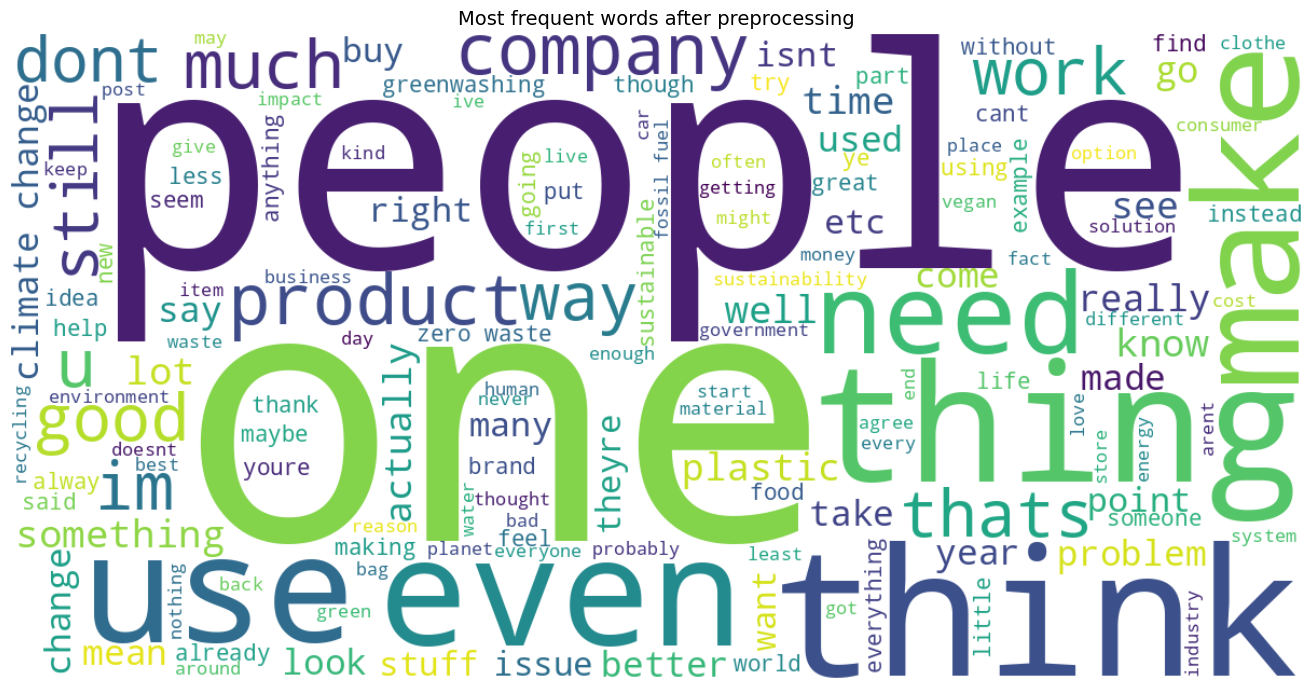

In [8]:
from wordcloud import WordCloud

text_all = ' '.join(df['text_clean'])

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(text_all)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words after preprocessing', fontsize=14)
plt.tight_layout()
plt.show()

## Custom Stopwords Extension

The initial wordcloud revealed a large number of high-frequency words 
that carry no thematic signal for this analysis: generic Reddit discourse 
markers (e.g. *people*, *think*, *thing*), informal contractions (*dont*, 
*isnt*, *cant*), intensifiers (*really*, *much*, *lot*) and generic verbs 
(*make*, *use*, *go*, *come*).

These words dominate the frequency distribution but contribute no useful 
information for topic modeling. They were added to the standard NLTK English 
stopword list before reapplying preprocessing.

In [9]:
custom_stopwords = {
    'people', 'one', 'think', 'thing', 'use', 'make', 'way', 'even',
    'dont', 'thats', 'isnt', 'doesnt', 'cant', 'im', 'youre', 'theyre', 'arent',
    'u', 'ye', 'etc', 'really', 'still', 'much', 'many', 'lot', 'well',
    'good', 'great', 'better', 'got', 'put', 'go', 'come', 'take', 'try',
    'say', 'feel', 'mean', 'seem', 'look', 'start', 'end', 'keep', 'would',
    'want', 'need', 'know', 'help', 'find', 'work', 'used', 'using',
    'something', 'anything', 'everything', 'nothing', 'someone', 'like', 'get',
    'also', 'back', 'around', 'first', 'every', 'never', 'always',
    'maybe', 'probably', 'though', 'already', 'enough', 'little',   'thing',
    'stuff', 'see', 'go', 'going', 'come', 'sure', 'actually', 'u', 'co',
    'right', 'yes', 'yeah', 'u', 'me', 'said', 'saying', 'didnt', 'wont',
    'thing', 'things', 'ive', 'u', 'time', 'point', 'thank', 'come', 'making'
}

stop_words_extended = stop_words | custom_stopwords

In [10]:
def preprocess_text_extendedstopwords(text):
    if pd.isna(text):
        return ''
    # 1. lowercase
    text = text.lower()
    # 2. remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. tokenize
    tokens = word_tokenize(text)
    # 4. remove stopwords
    tokens = [t for t in tokens if t not in stop_words_extended]
    # 5. lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [11]:
df['text_clean'] = df['Text'].apply(preprocess_text_extendedstopwords)
df[['Text', 'text_clean']].sample(3)

,Text,text_clean
1483,Ocean acidification has already killed us all.,ocean acidification killed u
8346,But we would need more land for farming to grow the vegetables that everyone would need to supplant their diets,land farming grow vegetable everyone supplant diet
27742,"I’ve discovered a company that sells bars that you can make a laundry liquid out of. I really don’t think the benefits outweigh the cons. They’re actively greenwashing their consumers. That in its own right is abhorrent.\nThen add the mass amounts of product that do not reach the right conditions, across millions of households, plus all the other plastic waste.. I don’t think it’s acceptable. Plus, if they’re researching ways to make it without it, they know it ain’t right and they’re still making the product, putting $ before everyone and everything else. Again, that says enough to me!",discovered company sell bar laundry liquid benefit outweigh con actively greenwashing consumer abhorrent add mass amount product reach condition across million household plus plastic waste acceptable plus researching way without aint product putting everyone else say


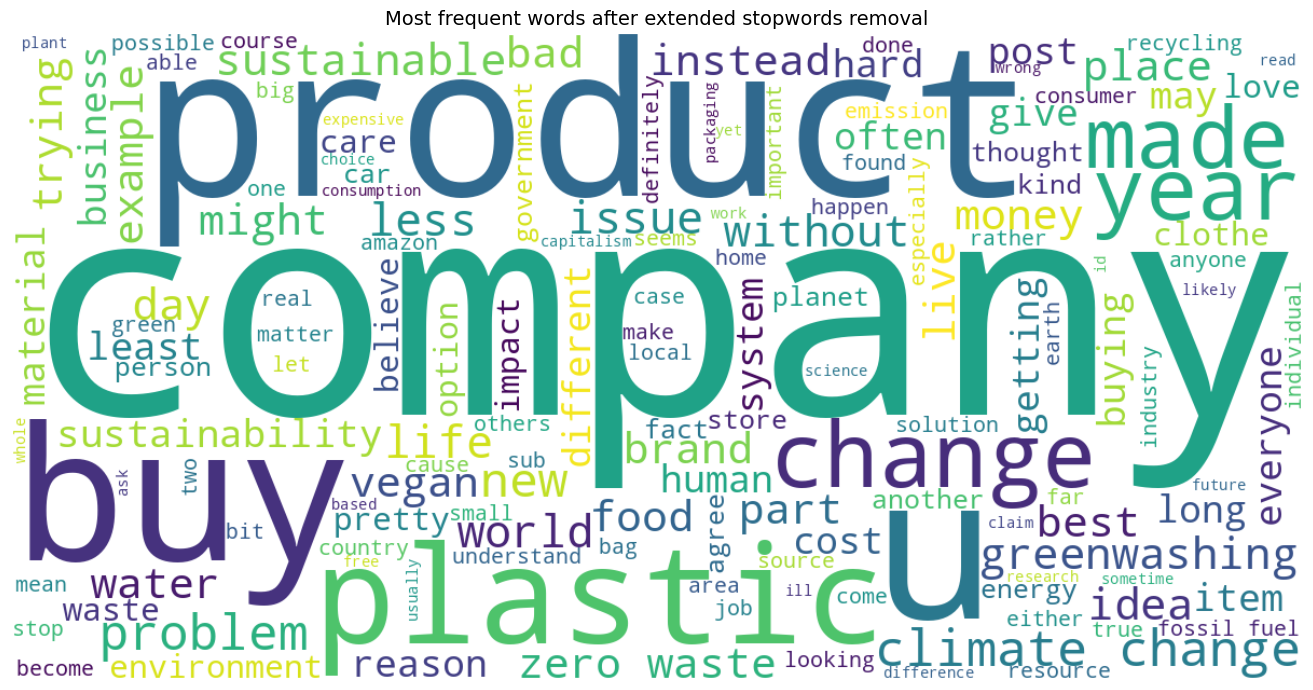

In [12]:
text_all = ' '.join(df['text_clean'])

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(text_all)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words after extended stopwords removal', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# CountVectorizer converts text into a matrix of word counts
# Each row = one document (post or comment)
# Each column = one word in the vocabulary
# The value in each cell = how many times that word appears in that document

vectorizer = CountVectorizer(
    max_features=5000,  # keep only the 5000 most frequent words (RAM friendly)
    min_df=5,           # ignore words that appear in fewer than 5 documents (too rare to be meaningful)
    max_df=0.95         # ignore words that appear in more than 95% of documents (too common to be meaningful)
)

# fit_transform learns the vocabulary AND transforms the text in one step
dtm = vectorizer.fit_transform(df['text_clean'])

print(f"Document-term matrix shape: {dtm.shape}")
# expected: (27849, something ≤ 5000)

Document-term matrix shape: (27849, 5000)


In [14]:
# LDA - Latent Dirichlet Allocation
# n_components = number of topics we ask LDA to find
# We start with 5 topics - we can adjust after seeing the results
# random_state = 42 for reproducibility
# n_jobs = 1 to avoid memory issues on 8GB RAM

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    n_jobs=1
)

# fit LDA on the document-term matrix
# this is the slow step - may take a few minutes
lda.fit(dtm)

print("Done!")

Done!


In [15]:
# show top 15 words for each topic
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: plastic | waste | water | product | zero | food | bottle | oil | container | packaging | soap | glass | less | meat | buy

Topic 2: change | climate | carbon | energy | year | world | emission | human | problem | fuel | impact | government | system | science | power

Topic 3: post | recycling | comment | plastic | car | question | please | thanks | read | ev | sub | paper | article | rule | link

Topic 4: bag | year | buy | life | live | clothes | buying | money | day | new | could | store | person | problem | tree

Topic 5: company | product | sustainable | brand | vegan | buy | business | amazon | greenwashing | sustainability | made | option | local | store | price


In [16]:
# LDA - Latent Dirichlet Allocation
# There seem to be topics with mixed topics inside
# Trial with 6 topics
# random_state = 42 for reproducibility
# n_jobs = 1 to avoid memory issues on 8GB RAM

lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    n_jobs=1
)

# fit LDA on the document-term matrix
# this is the slow step - may take a few minutes
lda.fit(dtm)

print("Done!")

Done!


In [17]:
# show top 15 words for each topic
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: waste | plastic | product | zero | food | company | sustainable | less | material | reduce | packaging | consumer | impact | water | greenwashing

Topic 2: change | climate | carbon | year | energy | human | world | emission | science | fuel | problem | fossil | system | government | global

Topic 3: plastic | post | comment | recycling | question | read | thanks | please | paper | sub | recycled | article | concern | rule | link

Topic 4: bag | buy | year | life | money | clothes | live | buying | problem | new | day | change | person | world | could

Topic 5: company | product | vegan | brand | amazon | tree | business | sustainable | buy | store | local | greenwashing | made | leather | could

Topic 6: car | water | oil | year | soap | ev | bottle | bar | skin | buy | product | wash | last | day | clean


In [18]:
# LDA - Latent Dirichlet Allocation
# There seem to be topics with mixed topics inside
# Trial with 7 topics
# random_state = 42 for reproducibility
# n_jobs = 1 to avoid memory issues on 8GB RAM

lda = LatentDirichletAllocation(
    n_components=7,
    random_state=42,
    n_jobs=1
)

# fit LDA on the document-term matrix
# this is the slow step - may take a few minutes
lda.fit(dtm)

print("Done!")

Done!


In [19]:
# show top 15 words for each topic
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: waste | plastic | product | zero | company | sustainable | material | water | greenwashing | reduce | consumer | less | green | impact | sustainability

Topic 2: climate | change | carbon | year | energy | human | emission | fuel | world | science | fossil | global | power | system | problem

Topic 3: post | comment | question | please | thanks | recycling | read | link | article | rule | action | concern | paper | plastic | check

Topic 4: bag | buy | year | clothes | life | money | change | buying | problem | new | individual | world | live | capitalism | person

Topic 5: plastic | product | company | brand | buy | amazon | store | business | bag | item | local | paper | container | packaging | made

Topic 6: car | year | water | oil | soap | ev | bar | skin | last | bottle | wash | day | ice | less | battery

Topic 7: vegan | tree | animal | meat | food | eat | plant | leather | could | diet | eating | idea | sustainable | environment | issue


## LDA Topic Exploration: Choosing the Optimal Number of Topics

LDA was run with n_components = 5, 6, and 7 to identify the most 
interpretable topic structure.

- **5 topics**: too broad - fashion/consumption and vegan diet 
  collapsed into a single incoherent topic
- **6 topics**: worse than 5 - topic coherence decreased, 
  and the mixed EV/personal care topic persisted
- **7 topics**: best result - topics are distinct and interpretable, 
  with the exception of Topic 6 (electric vehicles and daily products), 
  which reflects genuinely mixed content in the dataset 
  rather than a modeling artifact

**Decision: n_components = 7**

## Coherence Score Analysis (gensim c_v, Google Colab)

Coherence scores were computed via gensim on Google Colab (Python 3.12),
due to Python 3.14 compatibility issues with the local environment.

### Full dataset (n=27,849) — topics 2 to 10:

| n_topics | coherence |
|----------|-----------|
| 2 | 0.5388 |
| 3 | 0.5450 |
| 4 | 0.5363 |
| 5 | 0.5107 |
| 6 | 0.5188 |
| 7 | 0.5200 |
| 8 | 0.5634 |
| 9 | 0.5569 |
| 10 | 0.5575 |

Peak at n=8 (0.5634). n=7 selected for interpretability —
the marginal coherence gain of +0.043 does not justify
the added complexity of an additional topic.

In [20]:
# assign dominant topic to each document
# transform gives the topic probability distribution for each document
# argmax gives the topic with the highest probability
doc_topic_matrix = lda.transform(dtm)
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1) + 1  # +1 so topics go from 1 to 7

# count documents per topic
topic_counts = df['dominant_topic'].value_counts().sort_index()
print(topic_counts)
print(f"\nTotal documents: {len(df)}")
print(f"\nTopic 1 documents: {topic_counts[1]}")
print(f"Topic 1 percentage: {topic_counts[1]/len(df)*100:.1f}%")

dominant_topic
1    2937
2    5796
3    2255
4    5918
5    4179
6    2972
7    3792
Name: count, dtype: int64

Total documents: 27849

Topic 1 documents: 2937
Topic 1 percentage: 10.5%


([<matplotlib.patches.Wedge at 0x7f1e2f0a9550>,
 [Text(1.040176093058865, 0.3578179640945878, 'Greenwashing & Sustainability'),
  Text(0.276752272510679, 1.0646164472053656, 'Climate Change & Emissions'),
  Text(-0.6691083671213776, 0.8730944926227424, 'Recycling & Community'),
  Text(-1.0999858274164322, -0.005583859148226551, 'Fashion & Consumption'),
  Text(-0.4552526071288069, -1.0013715912199748, 'Packaging & Shopping'),
  Text(0.40800631308152885, -1.0215335767783738, 'Electric Vehicles & Daily Products'),
  Text(1.0008830914574414, -0.45632558248973415, 'Vegan Diet & Sustainability')],
 [Text(0.5673687780321081, 0.19517343496068423, '10.5%'),
  Text(0.1509557850058249, 0.5806998802938357, '20.8%'),
  Text(-0.3649682002480241, 0.47623335961240487, '8.1%'),
  Text(-0.599992269499872, -0.0030457413535781184, '21.3%'),
  Text(-0.2483196038884401, -0.5462026861199862, '15.0%'),
  Text(0.22254889804447028, -0.5572001327882038, '10.7%'),
  Text(0.5459362317040589, -0.24890486317621857,

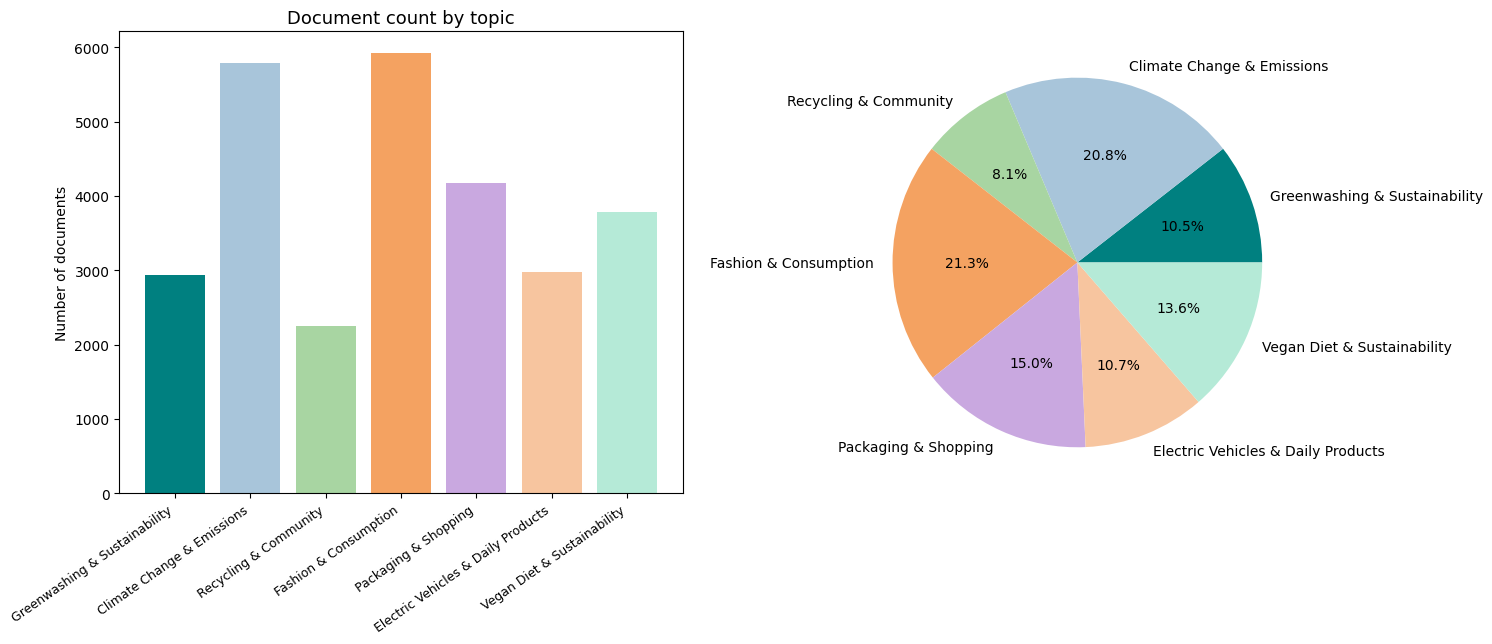

In [21]:
topic_labels = {
    1: 'Greenwashing & Sustainability',
    2: 'Climate Change & Emissions',
    3: 'Recycling & Community',
    4: 'Fashion & Consumption',
    5: 'Packaging & Shopping',
    6: 'Electric Vehicles & Daily Products',
    7: 'Vegan Diet & Sustainability'
}

colors_palette = {
    1: 'teal',
    2: '#a8c5da',  # light blue
    3: '#a8d5a2',  # light green
    4: '#f4a261',  # light orange
    5: '#c9a8e0',  # light purple
    6: '#f7c59f',  # peach
    7: '#b5ead7'   # mint
}

topic_counts_labeled = topic_counts.rename(index=topic_labels)
colors_bar = [colors_palette[i] for i in topic_counts.index]
pie_colors = [colors_palette[i] for i in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- barplot ---
axes[0].bar(range(len(topic_counts)), topic_counts.values, color=colors_bar)
axes[0].set_xticks(range(len(topic_counts)))
axes[0].set_xticklabels(topic_labels.values(), rotation=35, ha='right', fontsize=9)
axes[0].set_title('Document count by topic', fontsize=13)
axes[0].set_ylabel('Number of documents')

# --- pie chart ---
axes[1].pie(
    topic_counts.values,
    labels=topic_labels.values(),
    autopct='%1.1f%%',
    colors=pie_colors)

In [ ]:
df_greenwashing = df[df['dominant_topic'] == 1].copy()

print(f"Shape: {df_greenwashing.shape}")
print(f"Posts: {len(df_greenwashing[df_greenwashing['content_type']=='post'])}")
print(f"Comments: {len(df_greenwashing[df_greenwashing['content_type']=='comment'])}")

df_greenwashing.to_csv('../data/processed/df_greenwashing_topic1.csv', index=False)
print("✓ Saved!")

In [23]:
keywords = (
    'sunscreen|sun screen|suncream|sun cream|sunblock|sun block|'
    'reef|coral|oxybenzone|octinoxate|reef-safe|'
    'banana boat|hawaiian tropic|stream2sea|'
    'spf|mineral sunscreen|chemical sunscreen'
)

mask = df_greenwashing['Text'].str.contains(keywords, case=False, na=False)

sunscreen_docs = df_greenwashing[mask]
print(f"Documents mentioning sunscreen/reef topics: {len(sunscreen_docs)}")
print(f"\nPosts: {len(sunscreen_docs[sunscreen_docs['content_type']=='post'])}")
print(f"Comments: {len(sunscreen_docs[sunscreen_docs['content_type']=='comment'])}")

print("\n--- Sample texts ---")
print(sunscreen_docs[['content_type', 'Text', 'subreddit']].head(10).to_string())

Documents mentioning sunscreen/reef topics: 27

Posts: 5
Comments: 22

--- Sample texts ---
      content_type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Second-Level LDA: Greenwashing Subset

LDA applied to the greenwashing subset only (n=2,937) to identify 
internal sub-topics. This informs the stratified synthetic data 
generation strategy.

In [ ]:
df_greenwashing = pd.read_csv('../data/processed/df_greenwashing_topic1.csv', parse_dates=['Timestamp'])
print(f"Shape: {df_greenwashing.shape}")

In [25]:
df_greenwashing['text_clean'] = df_greenwashing['text_clean'].fillna('')

In [26]:
# max_features reduced to 2000 because the dataset is 10x smaller (2,937 vs 27,849 documents)
# a vocabulary of 5000 on this subset would produce a very sparse matrix
# with many columns appearing in too few documents to carry meaningful signal for LDA
vectorizer_gw = CountVectorizer(
    max_features=2000,  # smaller vocabulary for smaller dataset
    min_df=3,           # lower threshold because dataset is smaller
    max_df=0.95
)

dtm_gw = vectorizer_gw.fit_transform(df_greenwashing['text_clean'])
print(f"Document-term matrix shape: {dtm_gw.shape}")

Document-term matrix shape: (2937, 2000)


In [27]:
# we start with 4 topics because the subset is more homogeneous 
# it likely has less variance than the full dataset
# we will use coherence score to validate this choice
lda_gw = LatentDirichletAllocation(
    n_components=4,
    random_state=42,
    n_jobs=1
)

lda_gw.fit(dtm_gw)

# show top 15 words per topic
feature_names_gw = vectorizer_gw.get_feature_names_out()

for i, topic in enumerate(lda_gw.components_):
    top_words = [feature_names_gw[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: sustainable | company | water | material | sustainability | chemical | brand | product | environment | process | oil | environmental | standard | break | certification

Topic 2: plastic | waste | recycling | material | bag | recycled | glass | packaging | product | energy | food | bottle | recycle | less | made

Topic 3: waste | product | zero | company | sustainable | greenwashing | consumer | impact | change | buy | green | important | reduce | sustainability | example

Topic 4: detergent | company | laundry | product | sheet | powder | less | pva | water | pod | free | buy | liquid | consumer | greenwashing


In [28]:
# 5 topics trial
lda_gw = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    n_jobs=1
)

lda_gw.fit(dtm_gw)

# show top 15 words per topic
feature_names_gw = vectorizer_gw.get_feature_names_out()

for i, topic in enumerate(lda_gw.components_):
    top_words = [feature_names_gw[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: company | water | sustainability | product | sustainable | greenwashing | chemical | material | break | environment | green | environmental | certification | system | plastic

Topic 2: plastic | waste | recycling | material | recycled | packaging | glass | product | bag | bottle | recycle | food | energy | made | biodegradable

Topic 3: waste | zero | product | company | greenwashing | sustainable | consumer | change | impact | reduce | important | buy | lifestyle | trying | term

Topic 4: detergent | company | laundry | product | sheet | powder | less | free | pva | greenwashing | pod | plastic | liquid | buy | dishwasher

Topic 5: sustainable | brand | product | material | oil | fiber | organic | natural | made | cotton | clothing | ethical | fashion | clothes | fabric


In [29]:
# 6 topics trial
lda_gw = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    n_jobs=1
)

lda_gw.fit(dtm_gw)

# show top 15 words per topic
feature_names_gw = vectorizer_gw.get_feature_names_out()

for i, topic in enumerate(lda_gw.components_):
    top_words = [feature_names_gw[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: company | sustainability | water | product | sustainable | material | environment | system | chemical | certification | break | environmental | greenwashing | example | process

Topic 2: plastic | waste | material | recycling | recycled | glass | packaging | product | bag | biodegradable | energy | made | bottle | recycle | food

Topic 3: waste | zero | product | greenwashing | sustainable | change | company | consumer | important | impact | lifestyle | reduce | buy | term | life

Topic 4: product | company | detergent | laundry | green | less | greenwashing | sheet | plastic | consumer | water | buy | powder | free | waste

Topic 5: sustainable | brand | product | oil | organic | fiber | material | natural | clothing | made | fashion | ethical | fabric | clothes | synthetic

Topic 6: carbon | footprint | reduce | animal | bag | human | offset | corporation | water | company | food | emission | microplastics | consumer | place


In [ ]:
# assign dominant sub-topic to each document in the greenwashing subset
doc_topic_matrix_gw = lda_gw.transform(dtm_gw)
df_greenwashing['dominant_subtopic'] = doc_topic_matrix_gw.argmax(axis=1) + 1

subtopic_labels = {
    1: 'Certifications & Standards',
    2: 'Plastic & Recycling',
    3: 'Consumer Awareness & Greenwashing',
    4: 'Household Products & Greenwashing',
    5: 'Sustainable Fashion & Materials',
    6: 'Carbon Footprint & Corporate Responsibility'
}

df_greenwashing['subtopic_label'] = df_greenwashing['dominant_subtopic'].map(subtopic_labels)

# count per subtopic
subtopic_counts = df_greenwashing['dominant_subtopic'].value_counts().sort_index()
print(subtopic_counts)

df_greenwashing.to_csv('../data/processed/df_greenwashing_topic1.csv', index=False)
print("✓ Saved!")

### Coherence Score Analysis (gensim c_v)

### Greenwashing subset (n=2,937) — topics 2 to 8:

| n_topics | coherence |
|----------|-----------|
| 2 | 0.4009 |
| 3 | 0.3457 |
| 4 | 0.3552 |
| 5 | 0.3589 |
| 6 | 0.4145 |
| 7 | 0.3960 |
| 8 | 0.3813 |

**Decision: n_components = 6** — highest coherence score (0.4145),
consistent with qualitative evaluation of topic interpretability.

Colab notebook and plots: [add link after GitHub push]